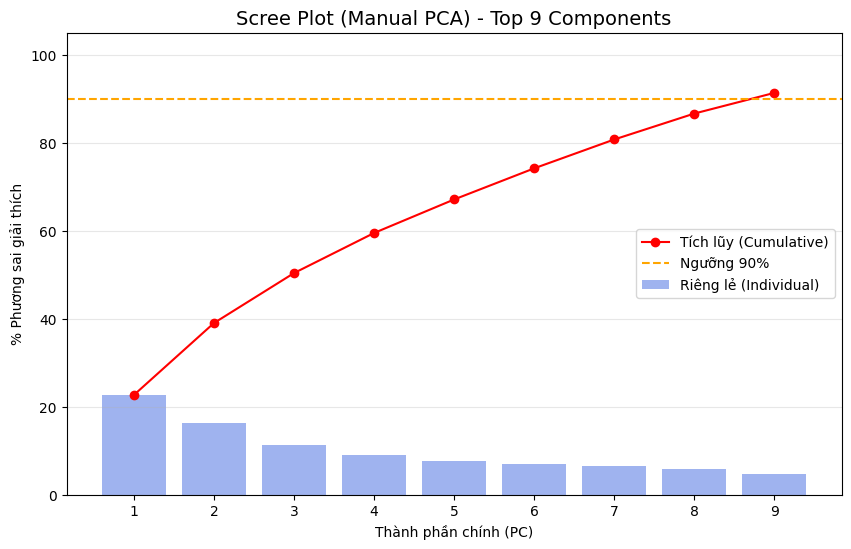


🔍 BÁO CÁO KẾT QUẢ PCA THỦ CÔNG:
- Tổng số biến ban đầu: 13
- Sau khi tính toán thủ công, tại PC thứ 9, phương sai tích lũy đạt 91.33%
- Kết luận: Việc chọn 9 PC là hoàn toàn hợp lý về mặt toán học.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. ĐỌC DỮ LIỆU
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

# Danh sách 13 biến khí tượng (giống bản Library)
target_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
               'precipitation', 'pressure', 'relative_humidity', 
               'temperature', 'uv_index', 'wind_speed']

df.columns = df.columns.str.strip().str.lower()
cols_found = [c for c in target_cols if c in df.columns]

# Xử lý Missing bằng Median và lọc dữ liệu số
X = df[cols_found].apply(pd.to_numeric, errors='coerce').fillna(df[cols_found].median(numeric_only=True))
X_values = X.values

# 2. TÍNH TOÁN PCA THỦ CÔNG (TOÁN HỌC)
# Bước A: Chuẩn hóa dữ liệu (Standardization)
X_std = (X_values - np.mean(X_values, axis=0)) / (np.std(X_values, axis=0) + 1e-8)

# Bước B: Tính ma trận hiệp phương sai (Covariance Matrix)
cov_mat = np.cov(X_std.T)
cov_mat = np.nan_to_num(cov_mat)

# Bước C: Tính Trị riêng (Eigenvalues) và Vectơ riêng (Eigenvectors)
eigen_vals, _ = np.linalg.eig(cov_mat)

# Bước D: Sắp xếp Trị riêng giảm dần và tính % phương sai
sorted_indices = np.argsort(np.real(eigen_vals))[::-1]
sorted_eigen = np.real(eigen_vals)[sorted_indices]

exp_var = (sorted_eigen / np.sum(sorted_eigen)) * 100
cum_var = np.cumsum(exp_var)

# 3. VẼ BIỂU ĐỒ SCREE PLOT (GIỚI HẠN 9 THÀNH PHẦN CHO ĐỒNG BỘ)
n_components_to_show = 9  # Chốt con số 9 để khớp với bản Library

plt.figure(figsize=(10, 6))

# Vẽ cột phương sai riêng lẻ
plt.bar(range(1, n_components_to_show + 1), exp_var[:n_components_to_show], 
        alpha=0.5, color='royalblue', label='Riêng lẻ (Individual)')

# Vẽ đường phương sai tích lũy
plt.plot(range(1, n_components_to_show + 1), cum_var[:n_components_to_show], 
         marker='o', color='red', label='Tích lũy (Cumulative)')

# Vẽ đường ngưỡng 90%
plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')

plt.title(f'Scree Plot (Manual PCA) - Top {n_components_to_show} Components', fontsize=14)
plt.xlabel('Thành phần chính (PC)'); plt.ylabel('% Phương sai giải thích')
plt.xticks(range(1, n_components_to_show + 1))
plt.ylim(0, 105) # Để biểu đồ không bị sát mép trên
plt.legend(loc='center right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. KẾT LUẬN
pc_90 = np.argmax(cum_var >= 90) + 1
print("\n" + "="*55)
print("🔍 BÁO CÁO KẾT QUẢ PCA THỦ CÔNG:")
print(f"- Tổng số biến ban đầu: {len(cols_found)}")
print(f"- Sau khi tính toán thủ công, tại PC thứ {pc_90}, phương sai tích lũy đạt {cum_var[pc_90-1]:.2f}%")
print(f"- Kết luận: Việc chọn {n_components_to_show} PC là hoàn toàn hợp lý về mặt toán học.")
print("="*55)